In [4]:
import matplotlib.pyplot as plt
ms = 500
n_tasks = 512
subtitle = f"n_tasks = {n_tasks}, each task is {ms}ms"
x_axis_workers = [1, 2, 4, 8, 10, 12, 16, 20, 26, 30, 36, 42, 48, 54, 60, 64]
target = [(ms * n_tasks)/i for i in x_axis_workers]
print(target)

[256000.0, 128000.0, 64000.0, 32000.0, 25600.0, 21333.333333333332, 16000.0, 12800.0, 9846.153846153846, 8533.333333333334, 7111.111111111111, 6095.238095238095, 5333.333333333333, 4740.740740740741, 4266.666666666667, 4000.0]


# Processes

In [46]:
processes = [
    [1024, []],
    [4096, []],
    [8192, []],
    [16384, []],
    [32768, []],
    [65536, []],
    [524288, []],
    [1048576, []],
]

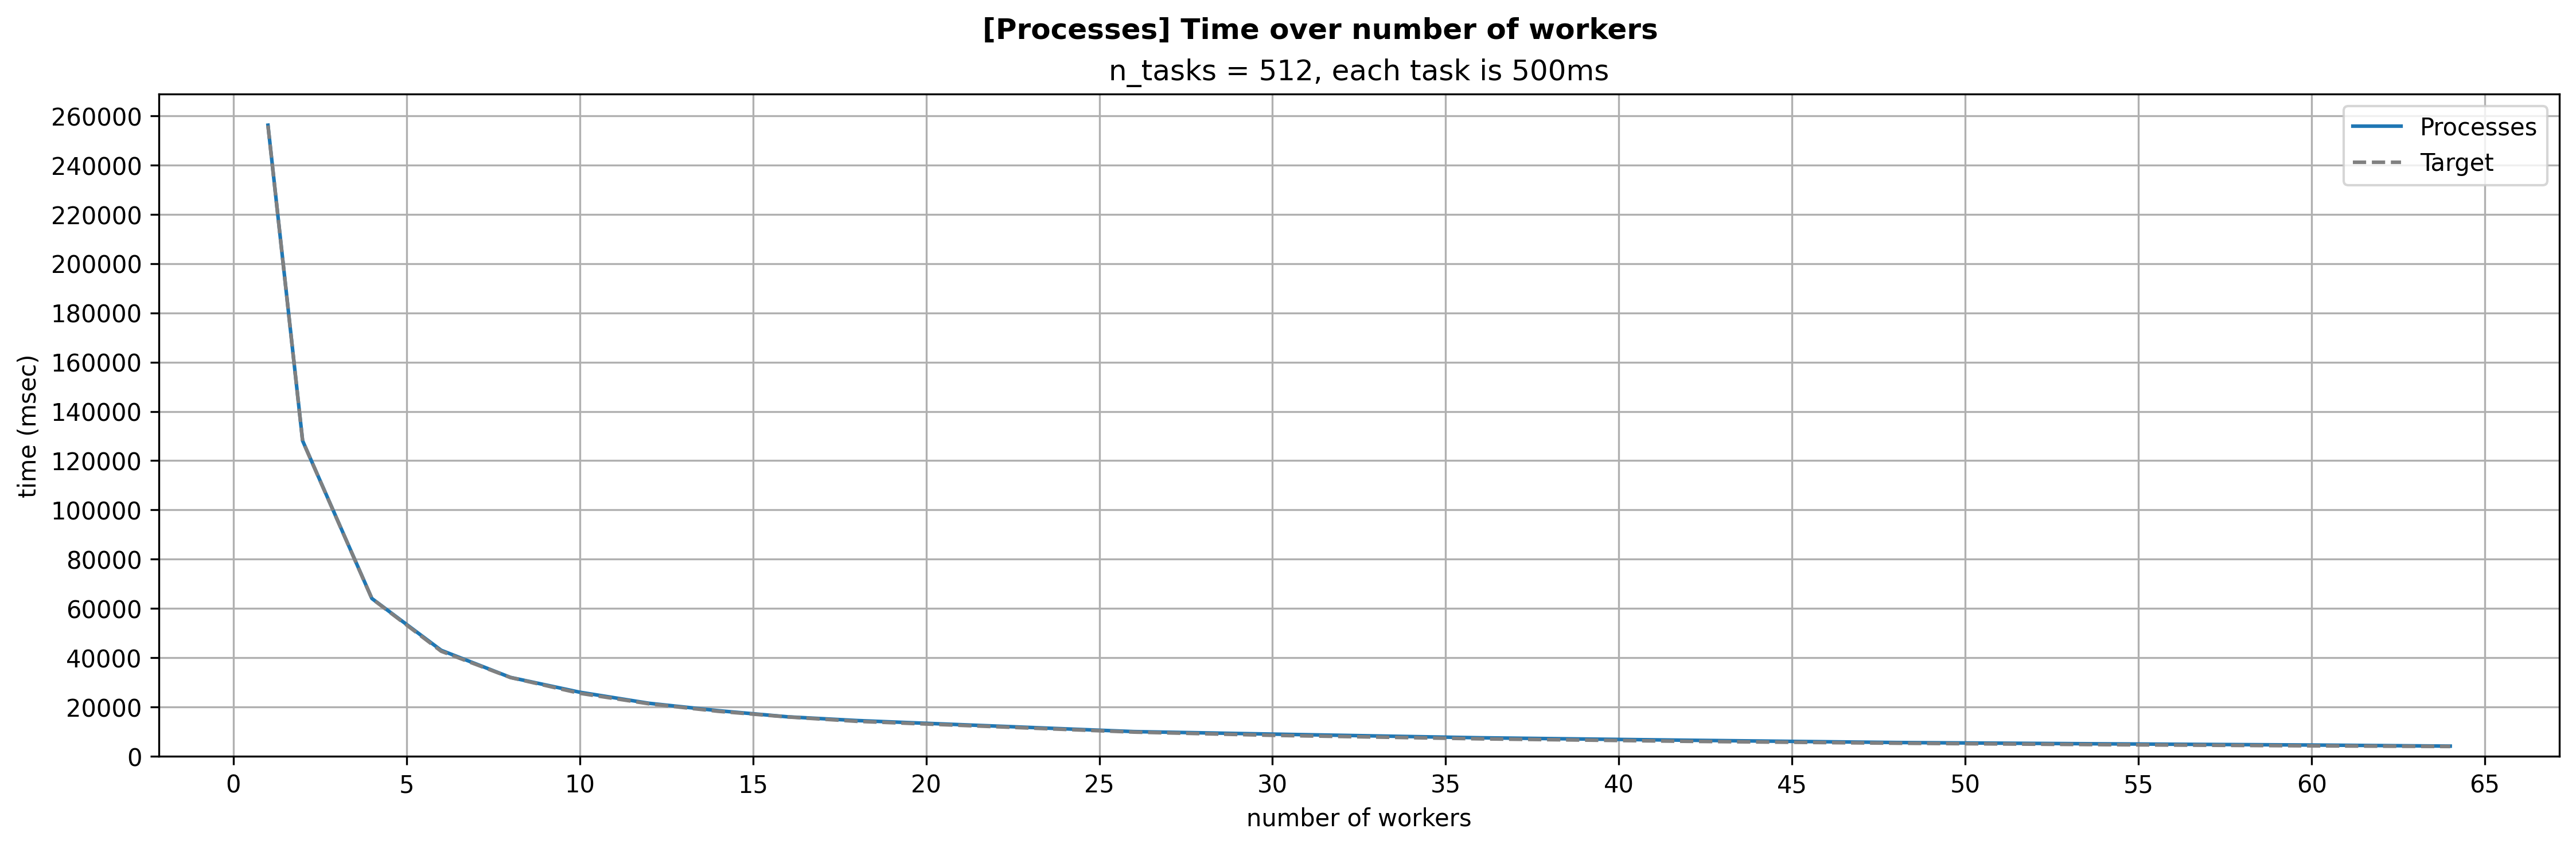

In [47]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
plt.locator_params(axis='y', nbins=24)
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")
plt.plot(processes[0], processes[1], label="Processes")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('[Processes] Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

# Subinterpreters

In [70]:
subinterpreters = [
    [1024, [256162.143, 128130.242, 64127.508, 32164.707, 26114.833, 21683.774, 16236.388, 13267.612, 10328.632, 9108.098, 7778.962, 6935.609, 6083.108, 5632.461, 5203.711, 4758.926]],
    #[4096, [256191.335, 128159.093, 64141.639, 32166.573]],
    #[8192, [256241.179, 128169.595, 64156.255]],
    #[16384, [256318.439, 128245.742, 64172.325]],
    [32768, [256524.308, 128330.061, 64228.638, 32218.372, 26157.956, 21738.501, 16291.467, 13309.458, 10322.435, 9160.156, 7962.681, 6963.309, 6140.735, 5652.135, 5238.661, 4834.767]],
    [65536, [256904.575, 128517.808, 64347.323, 32277.839, 26260.512, 21770.187, 16334.024, 13330.798, 10352.366, 9192.859, 7914.302, 7071.934, 6129.455, 5644.449, 5296.578, 4874.564]],
    [524288, [262401.702, 131404.925, 65953.802, 33160.156, 26907.05, 22424.512, 16991.265, 13903.537, 10945.236, 9610.245, 8650.063, 9254.527, 8621.812, 8579.763, 8644.079, 11539.303]],
    [1048576, [268441.466, 134586.894, 67706.176, 34171.897, 27661.482, 23183.289, 17923.934, 16443.776, 16393.936, 16116.689, 16272.314, 17457.888, 16589.831, 16408.188, 16320.762, 23001.959]],
]

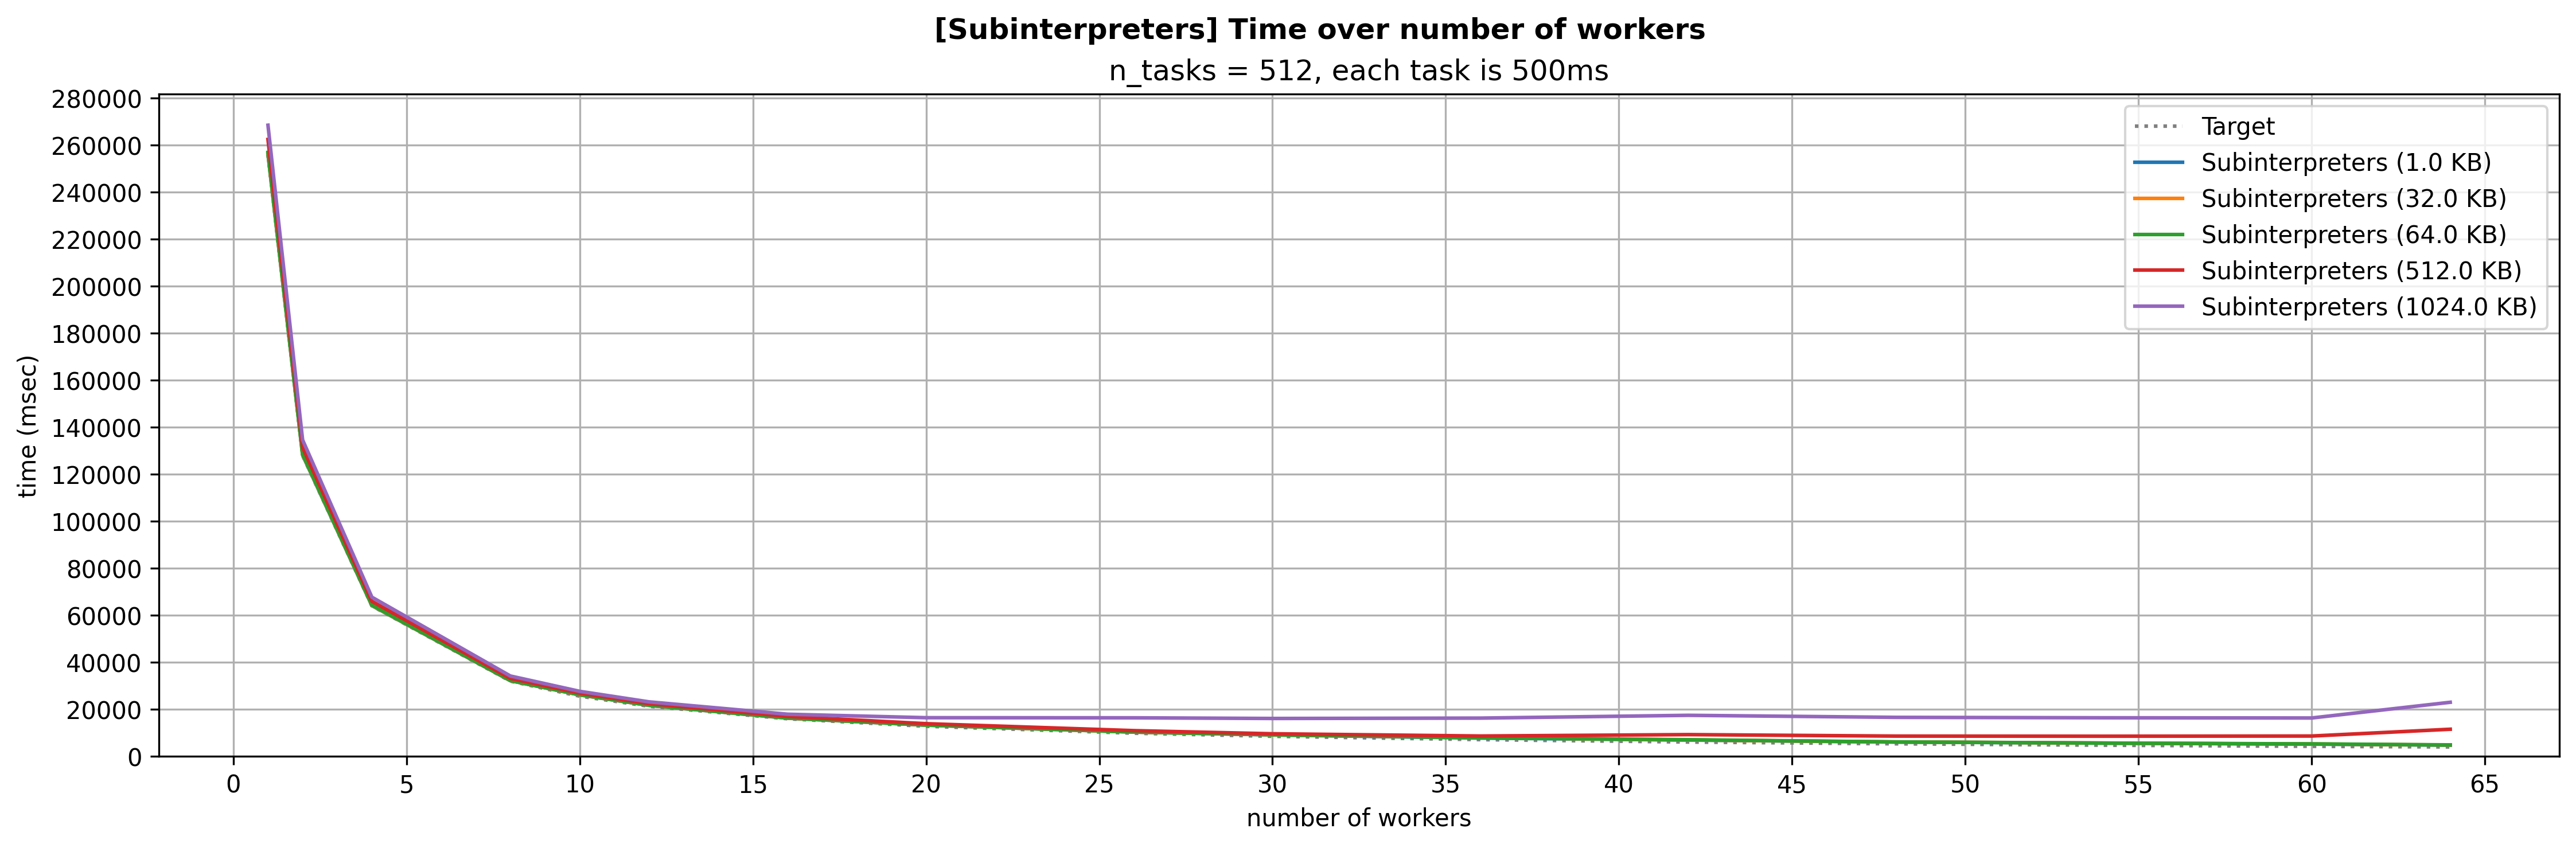

In [71]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
plt.locator_params(axis='y', nbins=24)
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")
for res in subinterpreters:
    ex = res[1]
    for v in range(len(x_axis_workers) - len(ex)):
        ex.append(ex[-1])
    plt.plot(x_axis_workers, ex, label=f"Subinterpreters ({res[0] / 1024} KB)")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('[Subinterpreters] Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

# Comparison

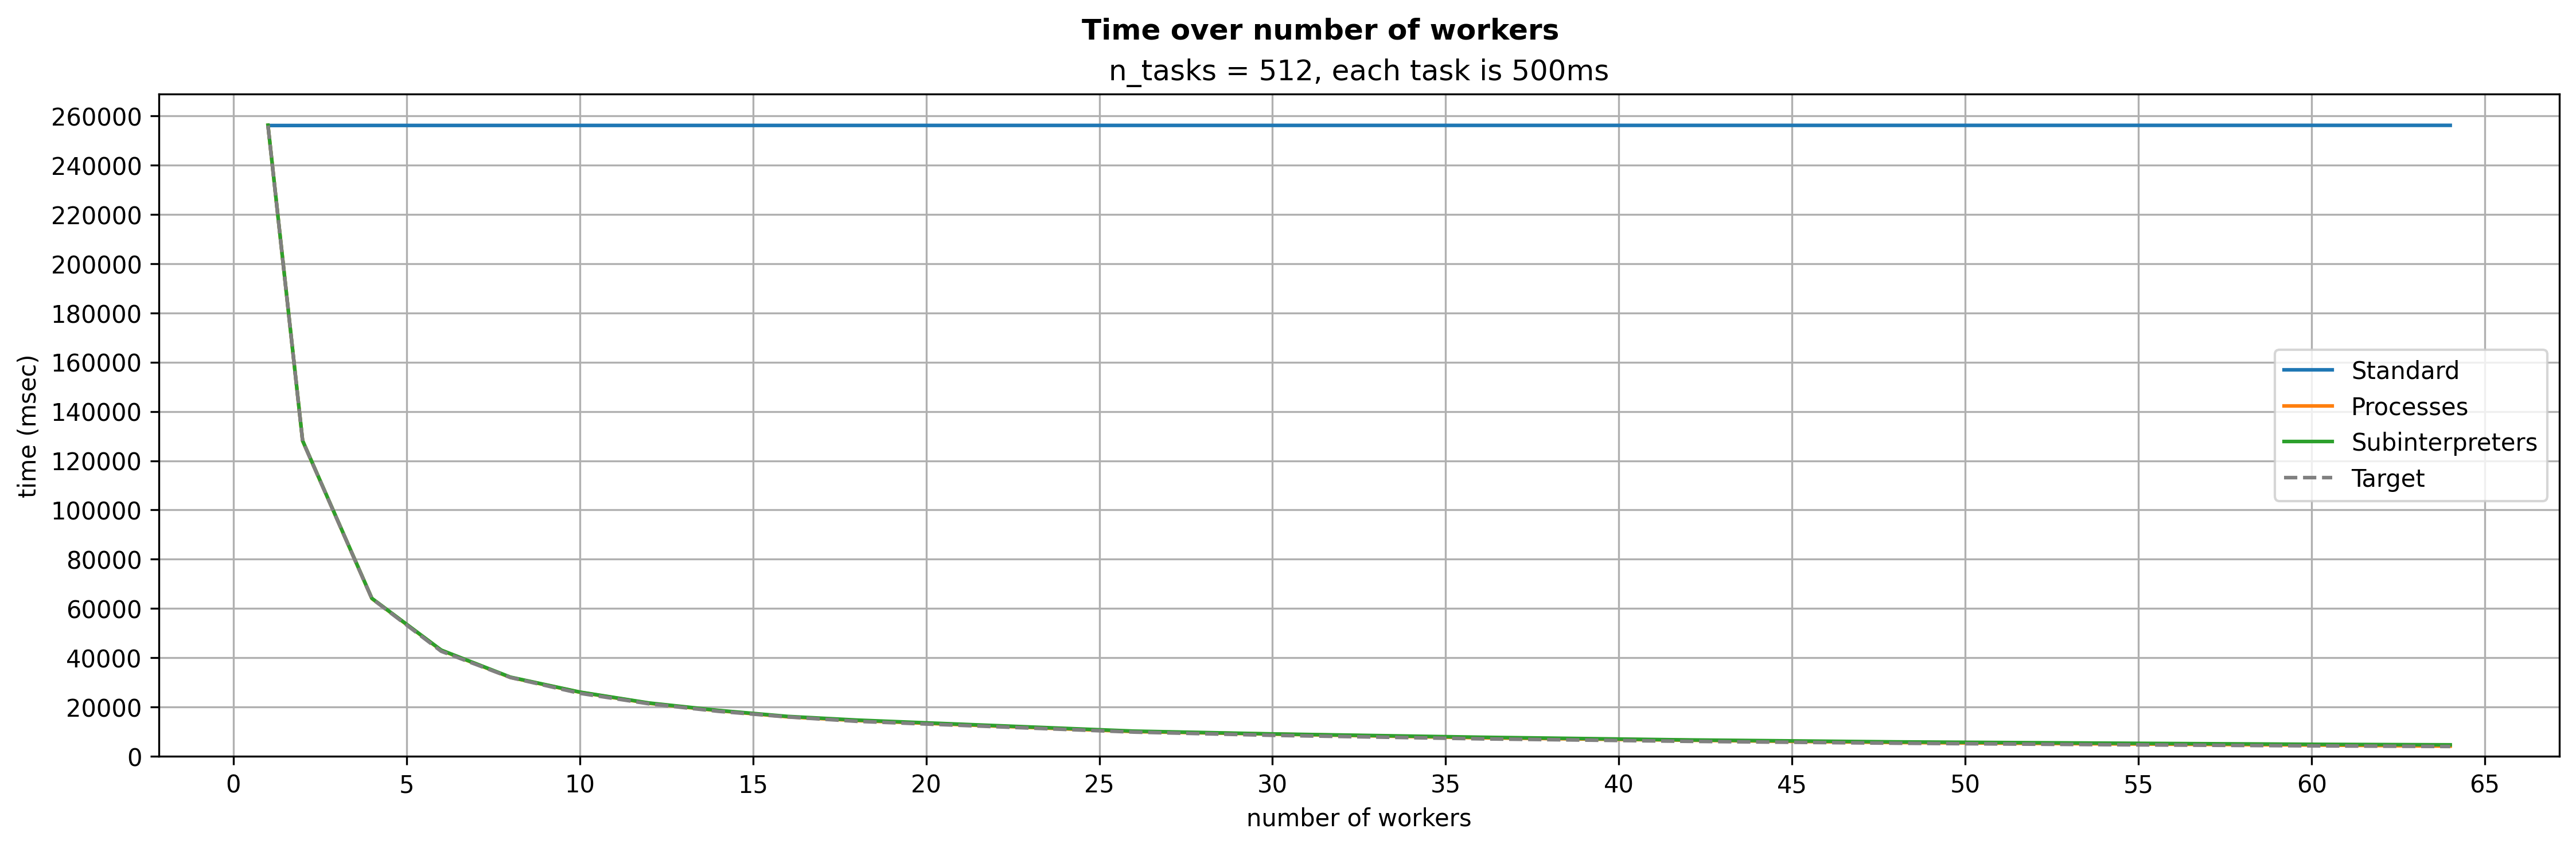

In [50]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(x_axis_workers)) 
plt.locator_params(axis='y', nbins=24)
plt.plot(processes[0], processes[1], label="Processes")
plt.plot(subinterpreters[0], subinterpreters[1], label="Subinterpreters")
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

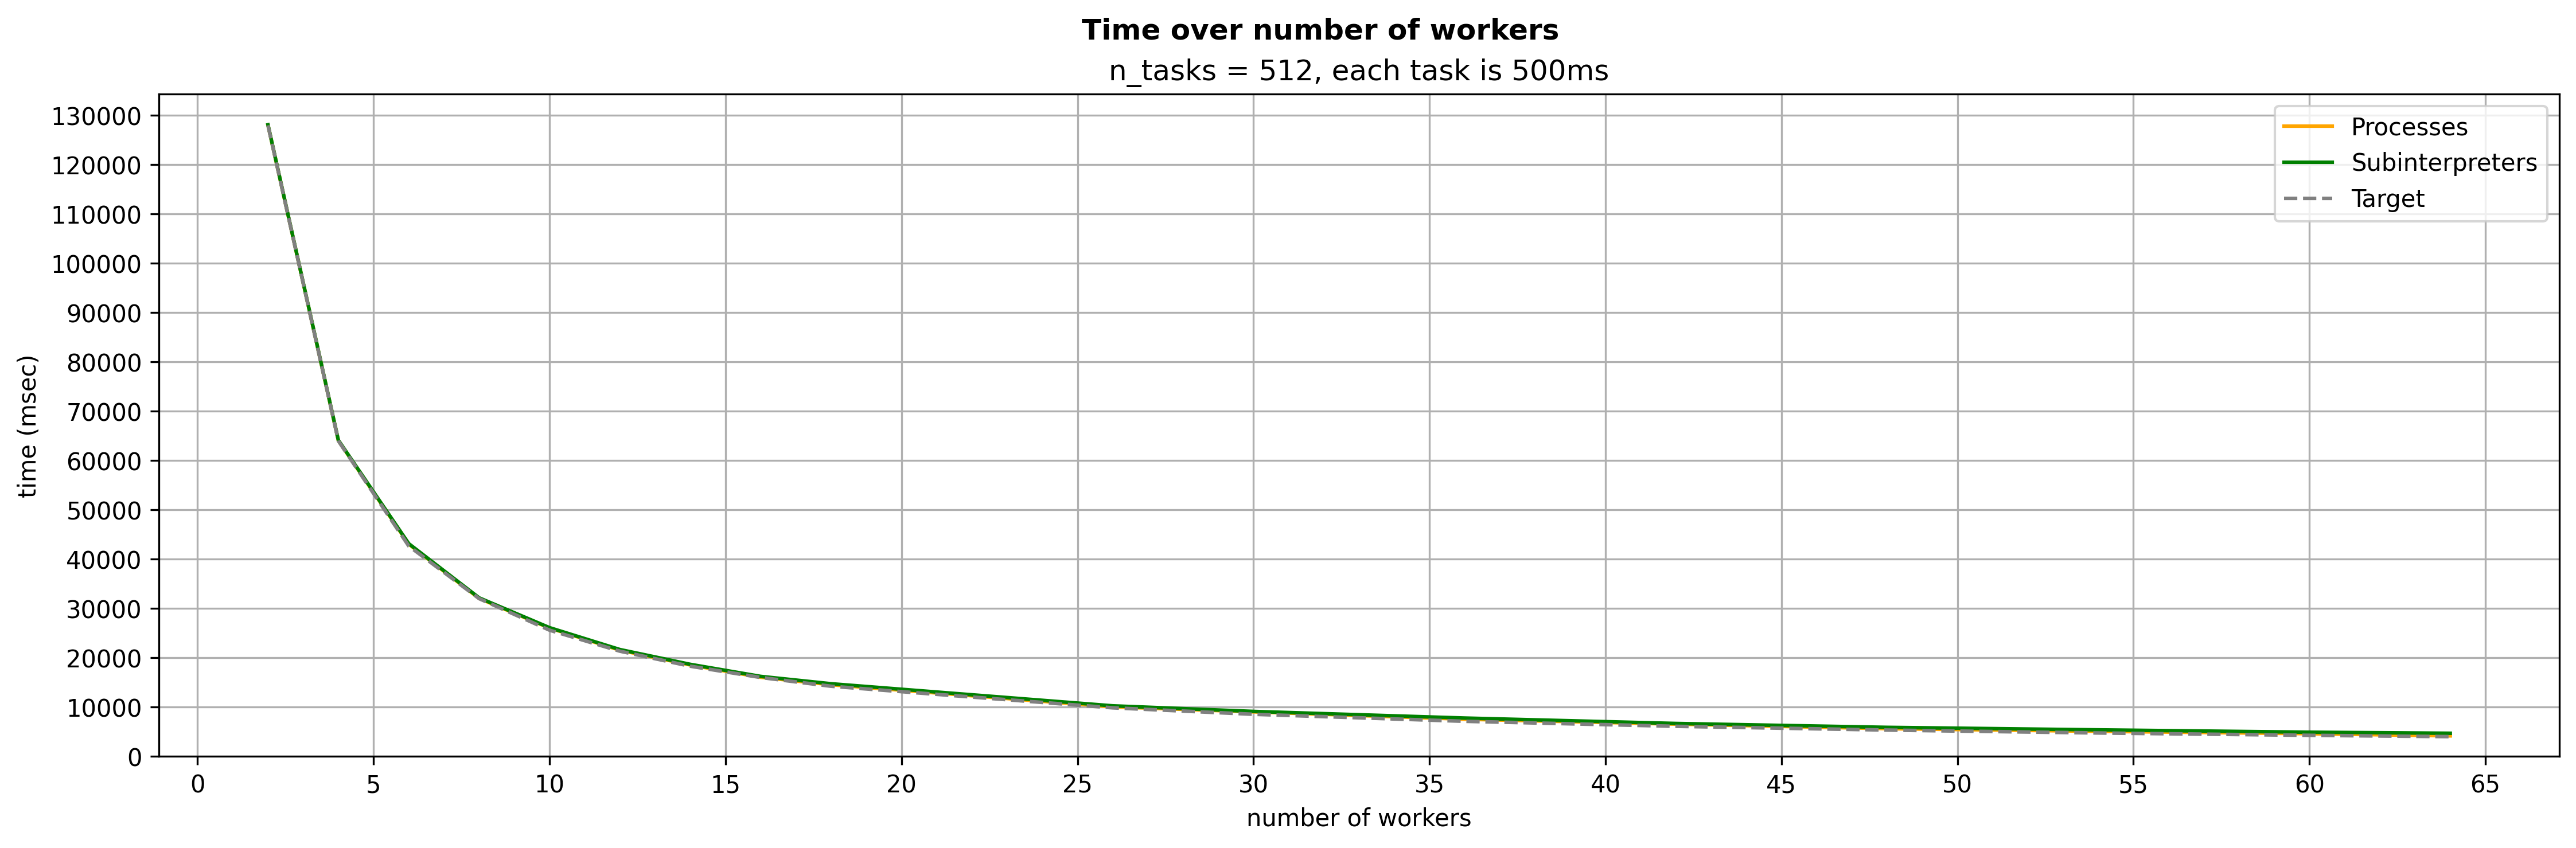

In [51]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(subinterpreters[0])) 
plt.locator_params(axis='y', nbins=24)
#plt.plot(standard[0][1:], standard[1][1:], label="Standard")
plt.plot(processes[0][1:], processes[1][1:], label="Processes", color="orange")
plt.plot(subinterpreters[0][1:], subinterpreters[1][1:], label="Subinterpreters", color="green")
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()

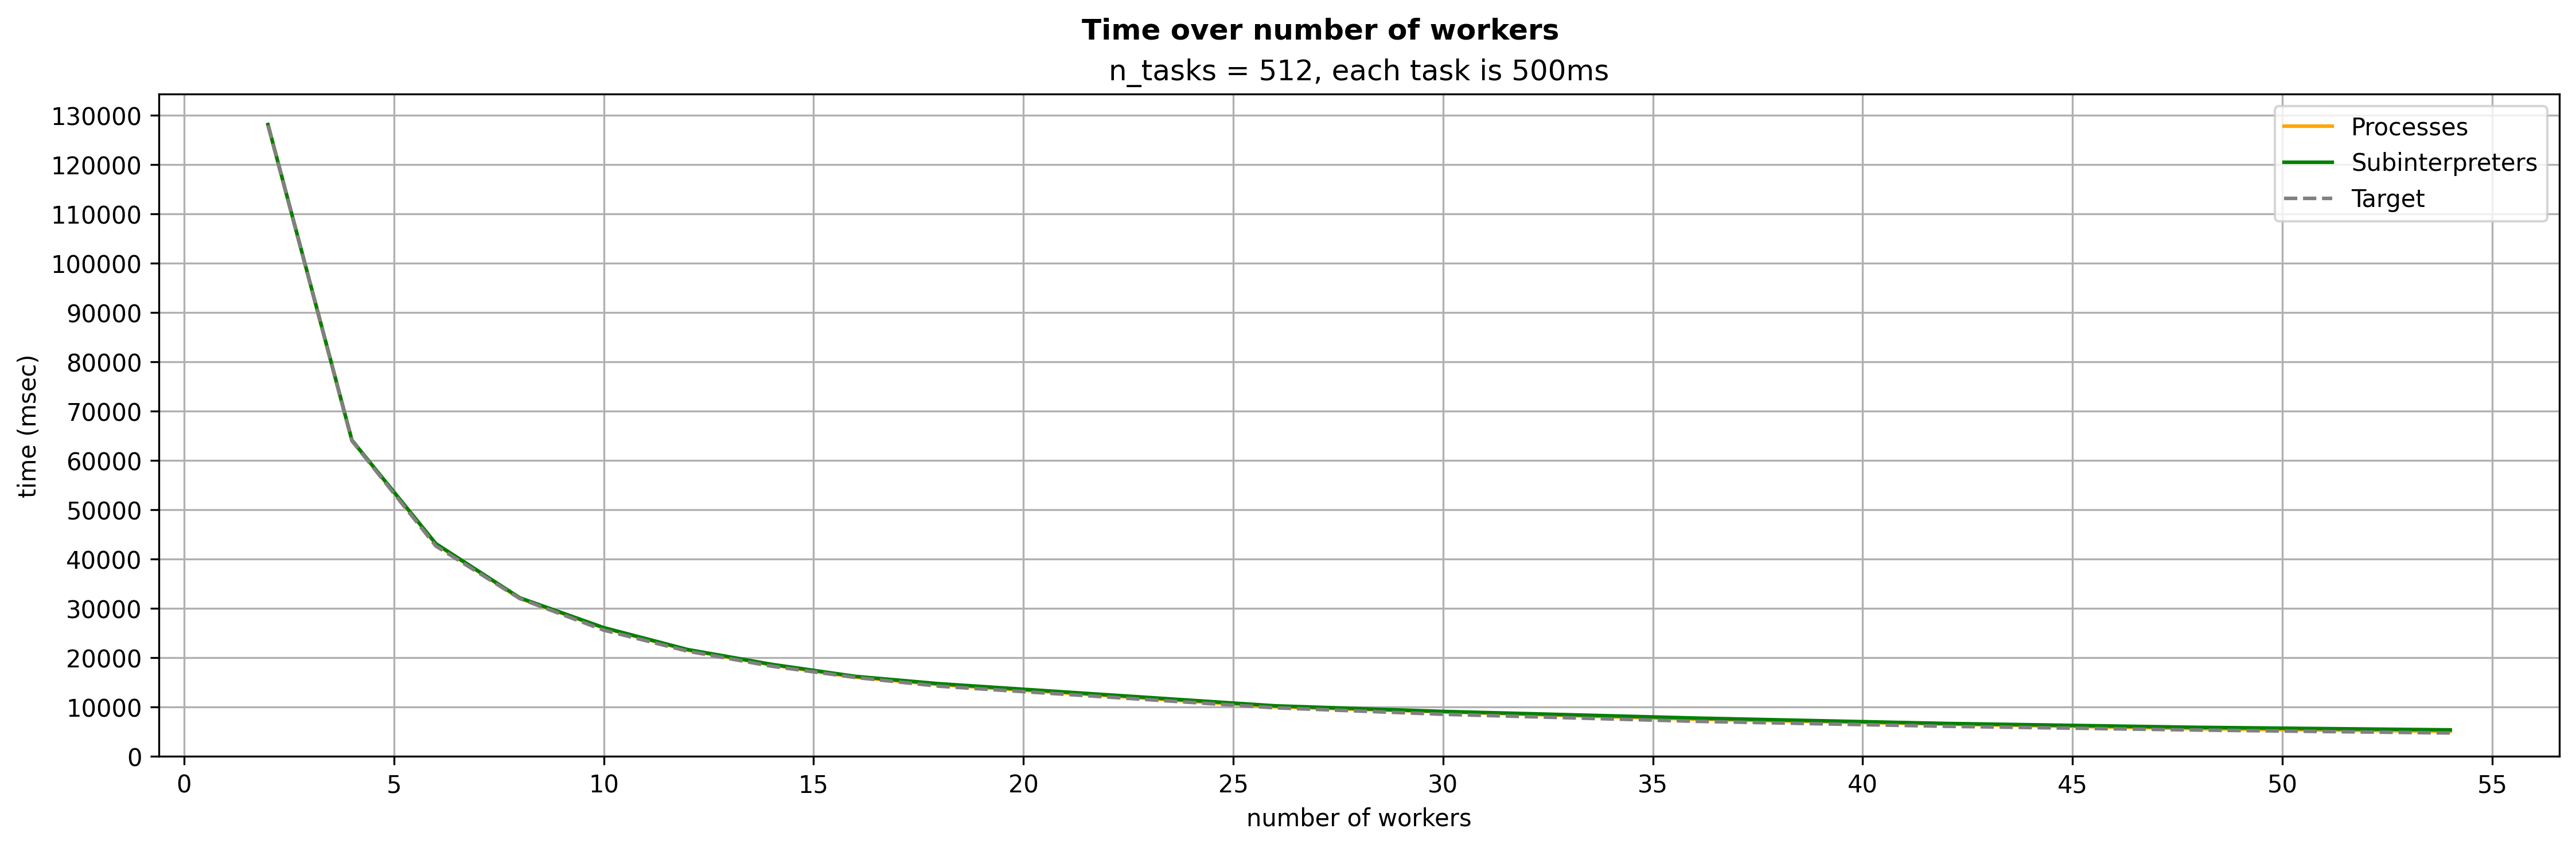

In [52]:
fig, axs = plt.subplots(figsize=(18, 5), dpi=300)
axs.grid()
# Setting the number of ticks
plt.locator_params(axis='x', nbins=len(subinterpreters[0][1:16])) 
plt.locator_params(axis='y', nbins=24)
#plt.plot(standard[0][1:], standard[1][1:], label="Standard")
plt.plot(processes[0][1:16], processes[1][1:16], label="Processes", color="orange")
plt.plot(subinterpreters[0][1:16], subinterpreters[1][1:16], label="Subinterpreters", color="green")
plt.plot(x_axis_workers, target, ls="dotted", label="Target", color="grey")

axs.set_xlabel("number of workers")
axs.set_ylabel("time (msec)")
axs.set_ylim(ymin=0)

plt.suptitle('Time over number of workers', y=0.97, fontweight="bold")
plt.title(subtitle)
plt.legend()
#savefig("stream_service_time")
plt.show()